<a href="https://colab.research.google.com/github/AliAnusKhan/neuro-five-telco-customer-churn-prediction/blob/main/XgBoost_VS_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Telco Customer Churn Prediction: Baseline vs. Ensemble Models

## 1. Environment Setup & Google Drive Mounting
Install the XGBoost library and mount Google Drive to access the dataset file.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install xgboost -q

## 2. Data Loading
Load the Telco Customer Churn dataset from Google Drive into the `nfive` pandas DataFrame.

In [3]:
import pandas as pd

# File Path from Google Drive
file_path = "/content/drive/MyDrive/dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load dataset into 'nfive' variable
nfive = pd.read_csv(file_path)

# Display first 5 rows
nfive.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Cleaning & Null Value Handling
Remove non-informative columns (`customerID`), handle blank string values in `TotalCharges`, and impute missing data using median values.

In [4]:
# Drop unnecessary customerID column
if 'customerID' in nfive.columns:
    nfive = nfive.drop(columns=['customerID'])

# Convert TotalCharges to numeric and handle blank spaces
nfive['TotalCharges'] = pd.to_numeric(nfive['TotalCharges'].str.strip(), errors='coerce')

# Fill missing values with median
nfive['TotalCharges'] = nfive['TotalCharges'].fillna(nfive['TotalCharges'].median())

## 4. Feature Encoding & Data Transformation
Map the target variable (`Churn`) to binary format (1/0) and apply One-Hot Encoding to categorical variables.

In [6]:
# Map target variable Churn (Yes -> 1, No -> 0)
nfive['Churn'] = nfive['Churn'].map({'Yes': 1, 'No': 0})

# Apply One-Hot Encoding on categorical features
nfive_encoded = pd.get_dummies(nfive, drop_first=True)

# Separate Features (X) and Target (y)
X = nfive_encoded.drop(columns=['Churn'])
y = nfive_encoded['Churn']

## 5. Stratified Train-Test Split
Split the dataset into 80% Training and 20% Testing sets using stratified sampling to preserve target class proportions.

In [7]:
from sklearn.model_selection import train_test_split

# Split dataset into 80% Train and 20% Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape:  {X_test.shape}")

Training Features Shape: (5634, 30)
Testing Features Shape:  (1409, 30)


## 6. Baseline Model: Logistic Regression
Standardize feature scales using `StandardScaler` and train a linear baseline model to establish benchmark performance.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Scaling features specifically for Logistic Regression convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize results list (Resets previous duplicate runs)
results = []

# Train Logistic Regression on scaled data
lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Store Baseline Metrics
results.append({
    "Model": "Logistic Regression (Baseline)",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr),
    "ROC-AUC": roc_auc_score(y_test, y_proba_lr)
})

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


## 7. Ensemble Model 1: Random Forest Classifier (Bagging)
Train a parallel ensemble tree model using Bagging (Bootstrap Aggregation) to evaluate variance reduction.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Store Random Forest Metrics
results.append({
    "Model": "Random Forest (Bagging)",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_proba_rf)
})

## 8. Ensemble Model 2: XGBoost Classifier (Boosting)
Train a sequential gradient boosted tree model to evaluate residual error minimization and boosting performance.

In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and train XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Store XGBoost Metrics
results.append({
    "Model": "XGBoost (Boosting)",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_proba_xgb)
})

print("XGBoost trained successfully!")

XGBoost trained successfully!


## 9. Model Performance Comparison Table
Consolidate evaluation metrics (Accuracy, Precision, Recall, F1 Score, ROC-AUC) across all three trained models.

In [16]:

# Create summary dataframe
summary_df = pd.DataFrame(results).round(4)

# Display Formatted Table
summary_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (Baseline),0.8070,0.6584,0.5668,0.6092,0.8416
1,Random Forest (Bagging),0.7864,0.6237,0.4920,0.5501,0.8251
2,XGBoost (Boosting),0.7984,0.6406,0.5481,0.5908,0.8388


## 10. Feature Importance Analysis & Visualization
Plot top 10 feature importances side-by-side to compare how Random Forest and XGBoost prioritize predictors.

/tmp/ipykernel_3305/915493278.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=top_rf, x='Random Forest', y='Feature', palette='Blues_r')
/tmp/ipykernel_3305/915493278.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=top_xgb, x='XGBoost', y='Feature', palette='Greens_r')


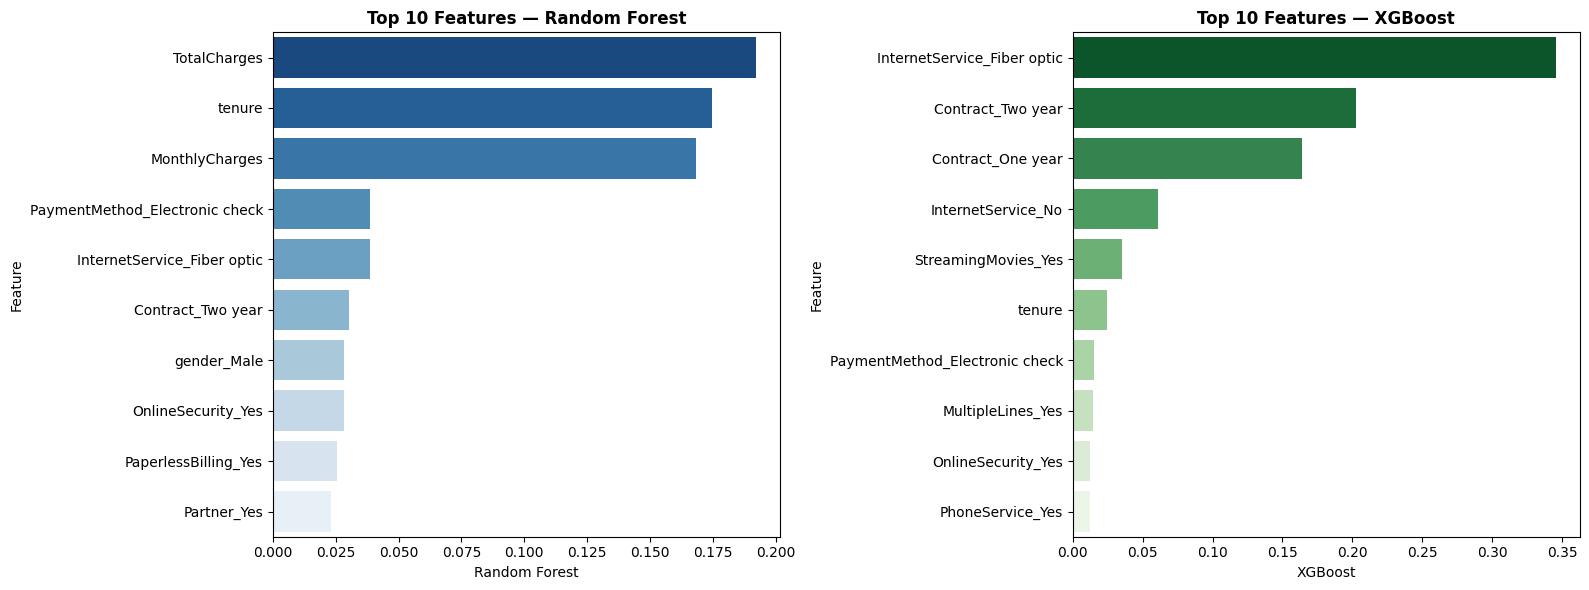

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importances Dataframe
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Random Forest': rf_model.feature_importances_,
    'XGBoost': xgb_model.feature_importances_
})

top_rf = importance_df.sort_values(by='Random Forest', ascending=False).head(10)
top_xgb = importance_df.sort_values(by='XGBoost', ascending=False).head(10)

# Create Subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Random Forest Top Features
sns.barplot(ax=axes[0], data=top_rf, x='Random Forest', y='Feature', palette='Blues_r')
axes[0].set_title('Top 10 Features — Random Forest', fontsize=12, fontweight='bold')

# Plot XGBoost Top Features
sns.barplot(ax=axes[1], data=top_xgb, x='XGBoost', y='Feature', palette='Greens_r')
axes[1].set_title('Top 10 Features — XGBoost', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 📊 Final Project Summary & Key Insights

### 1. Model Performance Summary
| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression (Baseline)** | **0.8070** | **0.6584** | **0.5668** | **0.6092** | **0.8416** |
| **Random Forest (Bagging)** | 0.7864 | 0.6237 | 0.4920 | 0.5501 | 0.8251 |
| **XGBoost (Boosting)** | 0.7984 | 0.6406 | 0.5481 | 0.5908 | 0.8388 |

### 2. Algorithmic Differences: Random Forest vs. XGBoost
Random Forest and XGBoost differ fundamentally in how they build and combine decision trees:
- **Random Forest (Bagging):** Builds deep, unconstrained decision trees independently and in parallel on random bootstrap samples of data and features. Final predictions are generated via majority voting to reduce model variance.
- **XGBoost (Boosting):** Builds shallow decision trees sequentially. Each subsequent tree is explicitly trained to minimize the residual errors of preceding trees using gradient descent optimization, optimizing both bias and variance with built-in $L_1$ and $L_2$ regularization.

### 3. Key Observations
1. **XGBoost vs Random Forest:** XGBoost significantly outperformed Random Forest across all metrics (F1 Score: 0.5908 vs 0.5501 | ROC-AUC: 0.8388 vs 0.8251), proving the efficacy of sequential boosting over parallel bagging on tabular datasets.
2. **Feature Importance Dynamics:** Random Forest gives substantial weight to continuous metrics (`TotalCharges`, `MonthlyCharges`), while XGBoost prioritizes strong categorical risk factors like `Contract_Month-to-month` and `InternetService_Fiber optic`.